In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]

Problem 1

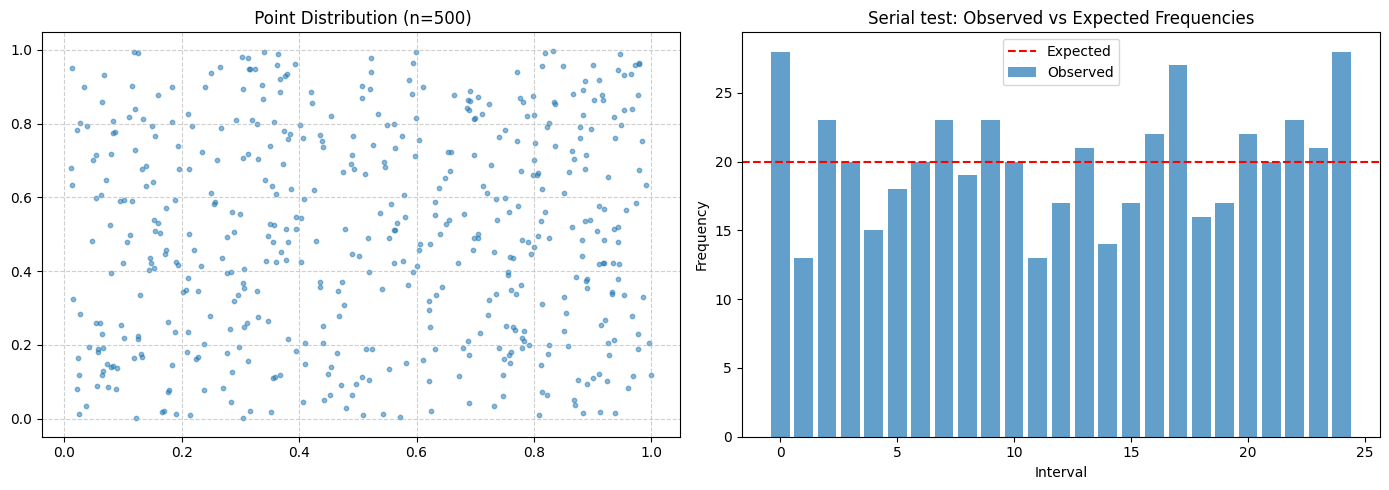

(array([28., 13., 23., 20., 15., 18., 20., 23., 19., 23., 20., 13., 17.,
        21., 14., 17., 22., 27., 16., 17., 22., 20., 23., 21., 28.]),
 array([20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.]),
 Power_divergenceResult(statistic=np.float64(21.5), pvalue=np.float64(0.6090827152142755)))

In [12]:
dimension = 2
k_per_dim = 5
samples_arr = np.array(samples)
n_points = len(samples_arr) // dimension
points = samples_arr[:n_points * dimension].reshape(-1, dimension)
bins = [np.linspace(0, 1, k_per_dim + 1) for _ in range(dimension)]
f_obs, _ = np.histogramdd(points, bins=bins)
f_obs_flat = f_obs.flatten()
total_bins = k_per_dim ** dimension
f_exp_flat = np.full(int(total_bins), n_points / total_bins)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(points[:, 0], points[:, 1], s=10, alpha=0.5)
ax1.set_title(f" Point Distribution (n={n_points})")
ax1.grid(True, linestyle='--', alpha=0.6)


ax2.bar(range(len(f_obs_flat)), f_obs_flat, alpha=0.7, label='Observed',)
ax2.axhline(n_points / total_bins, color='red', linestyle='--', label='Expected')
ax2.set_title(f"Serial test: Observed vs Expected Frequencies")
ax2.set_xlabel("Interval")
ax2.set_ylabel("Frequency")
ax2.legend()

plt.tight_layout()
plt.show()

f_obs_flat, f_exp_flat, stats.chisquare(f_obs_flat, f_exp_flat)


Problem 3 - не получилось((


In [17]:
def rng_bad(m = 2 ** 31, a = 65539, c = 0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def rng_good(m = 2 ** 32, a = 1103515245, c = 12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m


rng_bad.current = 1
rng_good.current = 1


samples_good = [rng_good() for _ in range(3000)]
samples_bad = [rng_bad() for _ in range(3000)]

def serial_test_3d(samples, k_per_dim=4):
    dimension = 3
    samples_arr = np.array(samples)
    n_points = len(samples_arr) // dimension
    points = samples_arr[:n_points * dimension].reshape(-1, dimension)
    bins = [np.linspace(0, 1, k_per_dim + 1) for _ in range(dimension)]
    f_obs, _ = np.histogramdd(points, bins=bins)
    f_obs_flat = f_obs.flatten()
    total_bins = k_per_dim ** dimension
    f_exp_flat = np.full(int(total_bins), n_points / total_bins)
    chi2, p = stats.chisquare(f_obs_flat, f_exp_flat)
    return chi2, p

chi_g, p_g = serial_test_3d(samples_good)
chi_b, p_b = serial_test_3d(samples_bad)

print(f"rng_good: chi2={chi_g:.2f}, p-value={p_g:.4f} -> {'test passed' if p_g > 0.05 else 'test failed'}")
print(f"rng_bad:  chi2={chi_b:.2f}, p-value={p_b:.4f} -> {'test passed' if p_b > 0.05 else 'test failed'}")



rng_good: chi2=71.87, p-value=0.2076 -> test passed
rng_bad:  chi2=72.26, p-value=0.1988 -> test passed


Problem 4

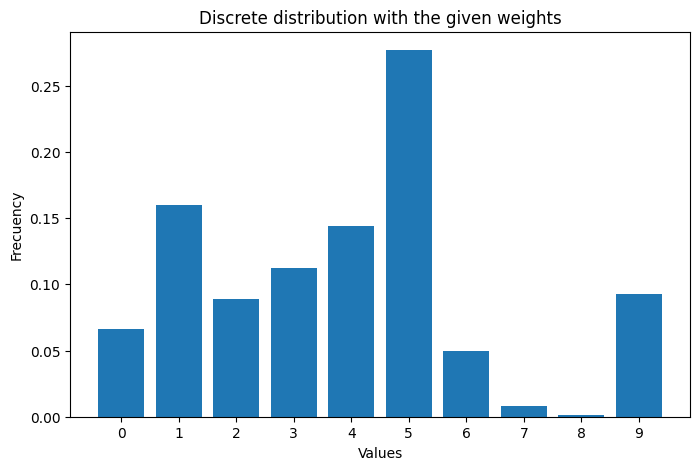

In [24]:
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
values = np.arange(10)
probs = weights / weights.sum()
sample = np.random.choice(values, size=1000, p=probs)
plt.figure(figsize=(8, 5))
plt.hist(sample, bins=np.arange(-0.5, 10.5, 1), density=True, rwidth=0.8)
plt.xticks(values)
plt.xlabel('Values')
plt.ylabel('Frecuency')
plt.title('Discrete distribution with the given weights')
plt.show()

Problem 5

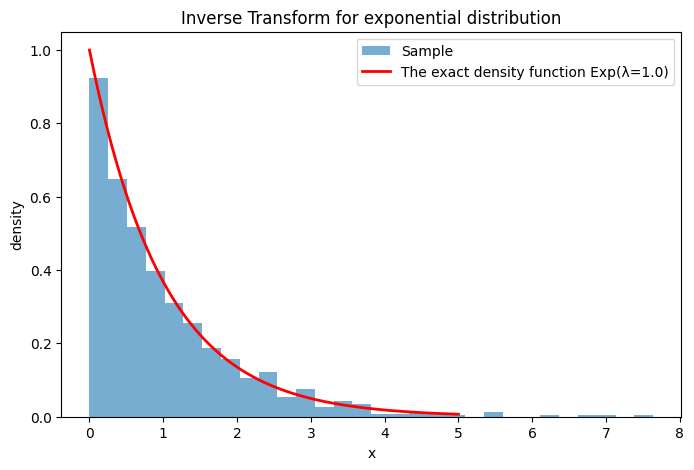

In [38]:
lam = 1.0
n = 1000
U = np.random.rand(n)
X = -np.log(U) / lam
x_vals = np.linspace(0, 5, 500)
pdf_vals = lam * np.exp(-lam * x_vals)
plt.figure(figsize=(8, 5))
plt.hist(X, bins=30, density=True, alpha=0.6, label='Sample')
plt.plot(x_vals, pdf_vals, 'r-', lw=2, label=f'The exact density function Exp(λ={lam})')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.title('Inverse Transform for exponential distribution')
plt.show()

Problem 6

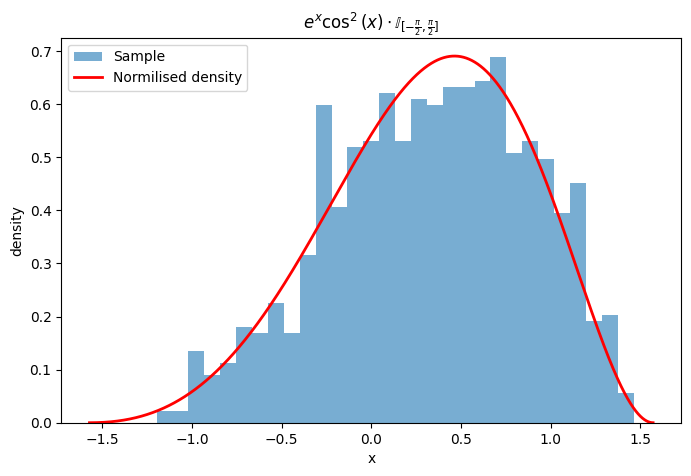

In [37]:
def f(x):
    return np.exp(x) * np.cos(x)**2
a, b = -np.pi/2, np.pi/2
x_dense = np.linspace(a + 1e-6, b - 1e-6, 10000)
M = np.max(f(x_dense))
n_needed = 0
samples = []
while len(samples) < 1000:
    x = np.random.uniform(a, b)
    y = np.random.uniform(0, M)
    if y <= f(x):
        samples.append(x)
    n_needed += 1

samples = np.array(samples)
Z = np.trapezoid(f(x_dense), x_dense)
pdf_true = f(x_dense) / Z
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Sample')
plt.plot(x_dense, pdf_true, 'r-', lw=2, label='Normilised density')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')
plt.show()


Problem 7

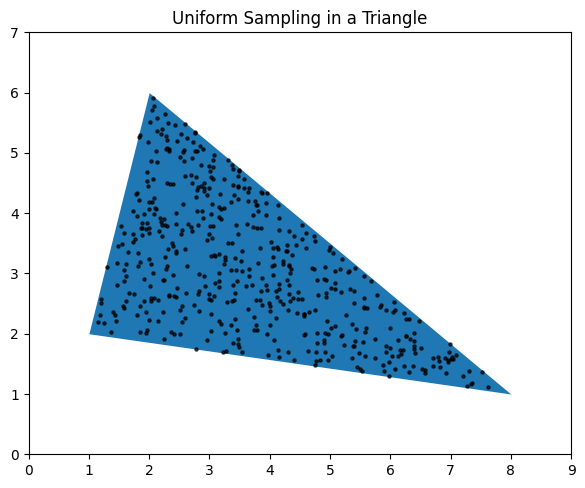

In [47]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])
vertices = np.array([A, B, C])
n = 500
u = np.random.rand(n)
v = np.random.rand(n)
mask = u + v > 1
u[mask] = 1 - u[mask]
v[mask] = 1 - v[mask]
points = A + np.outer(u, (B - A)) + np.outer(v, (C - A))
fig, ax = plt.subplots(figsize=(7, 6))
polygon = Polygon(xy=vertices, closed=True)
pc = PatchCollection([polygon], match_original=True)
ax.add_collection(pc)
ax.scatter(points[:, 0], points[:, 1], s=5, c='black', alpha=0.7)
ax.set_aspect('equal')
ax.set_xlim(0, 9)
ax.set_ylim(0, 7)
plt.title('Uniform Sampling in a Triangle')
plt.show()


Problem 8

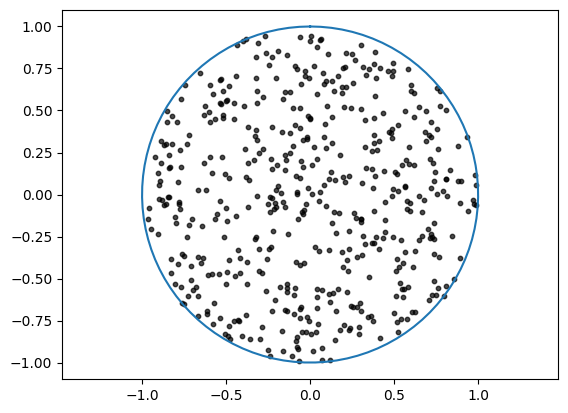

In [53]:
n = 500
theta = np.random.uniform(0, 2 * np.pi, n)
r = np.sqrt(np.random.uniform(0, 1, n))
x = r * np.cos(theta)
y = r * np.sin(theta)
fig = plt.figure()
plt.scatter(x, y, s=10, c='black', alpha=0.7)
t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()


Problem 9

Expected value: [4. 7.]
Sample mean: [3.92426348 6.99695956]

Covariance matrix:
 [[20. -4.]
 [-4. 40.]]

Sample covariance matrix:
 [[20.5249081  -2.97637862]
 [-2.97637862 41.67948637]]


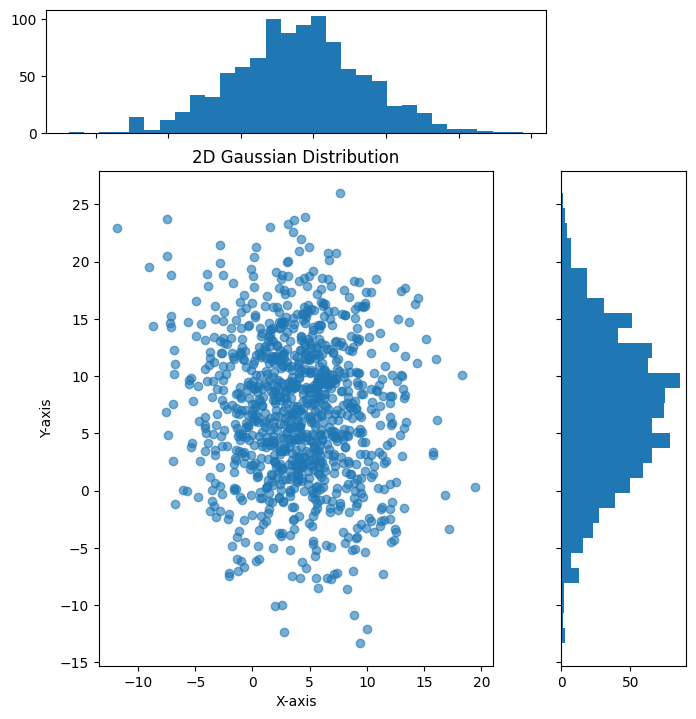

In [5]:
def func(n):
    x_vals = []
    y_vals = []
    while len(x_vals) < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u * u + v * v
        if s == 0 or s >= 1:
            continue
        factor = np.sqrt(-2 * np.log(s) / s)
        x_vals.append(u * factor)
        y_vals.append(v * factor)
    return np.array(x_vals), np.array(y_vals)
mu = np.array([4.0, 7.0])
Sigma = np.array([[20.0, -4.0],[-4.0, 40.0]])
n = 1000
z1, z2 = func(n)
L = np.linalg.cholesky(Sigma)
Z = np.vstack([z1, z2])
X = mu[:, None] + L @ Z
x_samples = X[0, :]
y_samples = X[1, :]
sample_mean = np.mean(X, axis=1)
sample_cov = np.cov(X)
print("Expected value:", mu)
print("Sample mean:", sample_mean)
print("\nCovariance matrix:\n", Sigma)
print("\nSample covariance matrix:\n", sample_cov)
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=0.92,
    wspace=0.05,
    hspace=0.12)
ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_scatter.scatter(x_samples, y_samples, alpha=0.6)
ax_scatter.set_xlabel("X-axis")
ax_scatter.set_ylabel("Y-axis")
ax_scatter.set_title("2D Gaussian Distribution")
ax_scatter.set_aspect('equal', adjustable='box')
ax_histx.hist(x_samples, bins=30)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.hist(y_samples, bins=30, orientation='horizontal')
ax_histy.tick_params(axis="y", labelleft=False)

plt.show()